In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import xarray as xr
import numpy as np
from pyproj import Transformer
from shapely.geometry import Point
import rasterio
import rioxarray
from scipy.spatial import cKDTree

In [2]:
### Distance Calculation to Nearest Wetland ###

# Load and prepare Thailand boundary
thailandmap = gpd.read_file('Data\\tha_admbnda_adm1_rtsd_20220121\\tha_admbnda_adm1_rtsd_20220121.shp')
min_lon, max_lat, max_lon, min_lat = thailandmap.union_all().bounds

# Load and subset land cover data
xr_landuse = xr.open_dataset("Data//dataset-satellite-land-cover//C3S-LC-L4-LCCS-Map-300m-P1Y-2022-v2.1.1.nc")
xr_landuse = xr_landuse.sel(lat=slice(min_lat, max_lat), lon=slice(min_lon, max_lon))
xr_landuse = xr_landuse.reindex(lat=xr_landuse.lat[::-1])
xr_landuse = xr_landuse.sel(time='2022-01-01').drop_vars('time')
lccs_resolution = 300  # meters

# Extract wetland areas (Class 180: herbaceous flooded / Class 210: water bodies)
wetland_mask = (xr_landuse['lccs_class'] == 180) | (xr_landuse['lccs_class'] == 210)

# Get all coordinates as arrays
lats = xr_landuse['lat'].values
lons = xr_landuse['lon'].values
lon_grid, lat_grid = np.meshgrid(lons, lats)

# Get wetland points in lat/lon
wetland_indices = np.where(wetland_mask.values)
wetland_lons = lon_grid[wetland_indices]
wetland_lats = lat_grid[wetland_indices]

# Vectorized coordinate transformation (EPSG:4326 to EPSG:3857 for meters)
transformer = Transformer.from_crs('EPSG:4326', 'EPSG:3857', always_xy=True)
wetland_x, wetland_y = transformer.transform(wetland_lons, wetland_lats)
wetland_points_proj = np.column_stack([wetland_x, wetland_y])

# Transform all grid points
all_x, all_y = transformer.transform(lon_grid.ravel(), lat_grid.ravel())
all_points_proj = np.column_stack([all_x, all_y])

# Build KDTree for efficient spatial queries
tree = cKDTree(wetland_points_proj)
distances, _ = tree.query(all_points_proj, k=1, workers=-1)
distance_grid = distances.reshape(lon_grid.shape)

# Create xarray with distances
xr_distance = xr.Dataset(
    {'distance': (['lat', 'lon'], distance_grid)},
    coords={'lat': lats, 'lon': lons}
)

print("Distance calculation complete")
print(f"Grid shape: {distance_grid.shape}")
print(f"Wetland points found: {len(wetland_points_proj)}")
print(f"Min distance: {np.min(distances):.2f}m, Max distance: {np.max(distances):.2f}m")

Distance calculation complete
Grid shape: (5346, 2985)
Wetland points found: 6064170
Min distance: 0.00m, Max distance: 72028.95m


In [3]:
### Optimized SI calculation using vectorized NumPy operations ###

# Load existing landcover SI mask
xr_landuse_si = xr.open_dataset('Output\\xr_SI_Landcover.nc')

# Get distance array
dist = xr_distance['distance'].values

# Define distance thresholds (base constraint + 300m pixel resolution buffer)
threshold_bgec_biomass = 500 + lccs_resolution
threshold_solar_wind = 400 + lccs_resolution
threshold_msw1 = 300 + lccs_resolution
threshold_msw2 = 600 + lccs_resolution
threshold_msw3 = 900 + lccs_resolution

# BGEC, Biomass, BGWW: 0 if < 500m + res, else 3
si_bgec = np.where(dist < threshold_bgec_biomass, 0, 3).astype(float)
si_biomass = np.where(dist < threshold_bgec_biomass, 0, 3).astype(float)
si_bgww = np.where(dist < threshold_bgec_biomass, 0, 3).astype(float)

# Solar & Wind: 0 if < 400m + res, else 3
si_solar = np.where(dist < threshold_solar_wind, 0, 3).astype(float)
si_wind = np.where(dist < threshold_solar_wind, 0, 3).astype(float)

# MSW and IEW: Stepped suitability
si_msw = np.where(
    dist < threshold_msw1, 0,
    np.where(
        dist < threshold_msw2, 1,
        np.where(dist < threshold_msw3, 2, 3)
    )
).astype(float)

si_iew = np.copy(si_msw)

# Apply landcover mask (set to 0 where landcover SI is 0)
for si_arr, si_name in [(si_bgec, 'SI_BGEC'), (si_biomass, 'SI_Biomass'), 
                         (si_wind, 'SI_Wind'), (si_solar, 'SI_Solar'),
                         (si_bgww, 'SI_BGWW'), (si_msw, 'SI_MSW'), (si_iew, 'SI_IEW')]:
    si_arr[xr_landuse_si[si_name].values == 0] = 0

# Create xarray dataset with all SI variables
xr_si_distance = xr.Dataset(
    {
        'SI_BGEC': (['lat', 'lon'], si_bgec),
        'SI_Biomass': (['lat', 'lon'], si_biomass),
        'SI_Wind': (['lat', 'lon'], si_wind),
        'SI_Solar': (['lat', 'lon'], si_solar),
        'SI_BGWW': (['lat', 'lon'], si_bgww),
        'SI_MSW': (['lat', 'lon'], si_msw),
        'SI_IEW': (['lat', 'lon'], si_iew),
    },
    coords={'lat': lats, 'lon': lons}
)

print("Wetland SI calculation mapping generated successfully.")

Wetland SI calculation mapping generated successfully.


In [4]:
# Save to NetCDF
xr_si_distance.to_netcdf(path='Output\\xr_SI_Distancetowetland.nc')
print("Distance to wetland suitability index saved successfully.")
print(xr_si_distance)

Distance to wetland suitability index saved successfully.
<xarray.Dataset> Size: 894MB
Dimensions:     (lat: 5346, lon: 2985)
Coordinates:
  * lat         (lat) float64 43kB 5.615 5.618 5.621 5.624 ... 20.46 20.46 20.46
  * lon         (lon) float64 24kB 97.35 97.35 97.35 97.35 ... 105.6 105.6 105.6
Data variables:
    SI_BGEC     (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SI_Biomass  (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SI_Wind     (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SI_Solar    (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SI_BGWW     (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SI_MSW      (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SI_IEW      (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0


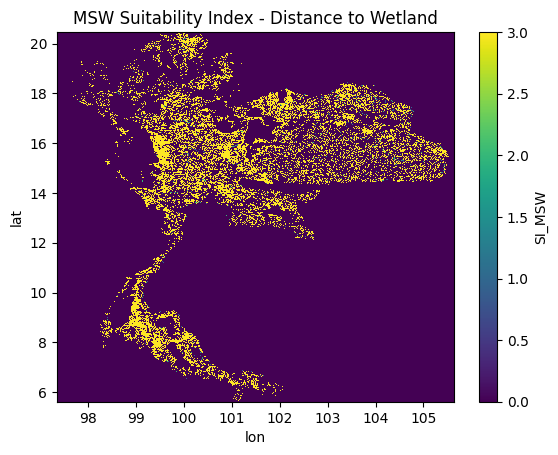

In [10]:
# Plot MSW as a visual check
xr_si_distance['SI_MSW'].plot()
plt.title('MSW Suitability Index - Distance to Wetland')
plt.show()